*NOTE*: notebook generated by Claude

# PR #664 spatial-disaggregation fix comparison — rsds, global

Compares three global `CESM2-WACCM` / `rsds` / `BCSD` runs (SSP245 ensemble member `003`, historical ensemble member `r3i1p1f1`), all on the same icechunk store:

`s3://carbonplan-srm/scratch/snapshot/output/qa/CESM2-WACCM-ERA5-global.icechunk`

| label | branch | what it is |
|---|---|---|
| `baseline` | `add-qdmsd-snapshot-test002` | pre-PR #664 (production disaggregation) |
| `simple_rolling` | `pr664-global-simple-rolling-mean-test002` | `disaggregation_clim_method="simple_rolling"` candidate fix |
| `tiny_thresh` | `pr664-global-tiny-thresh-on-test001` | `disaggregation_tiny_threshold` candidate fix |

Both candidates target the near-zero-climatology multiplicative-disaggregation blow-up investigated regionally in `notebooks/QA_QC/spatial_disaggregation/` (Alaska/rsds, East Africa/pr, South Africa/pr). This notebook re-runs the relevant checks from `srm.qa_flags` / `srm.qaqc` at global scale to see whether either fix introduces its own artifacts, without writing anything back to the production flag store.

Checks two outputs per branch/scenario: the final downscaled (fine ERA5 grid) output, and the pre-disaggregation `debiased_coarse` output (native GCM grid) — the latter should be identical across branches since PR #664 only touches disaggregation, which the sanity check below verifies directly rather than assuming.

**Leaf availability is checked at run time** (see below) and every section skips/labels branches or scenarios that are missing the data a given check needs rather than failing.

In [1]:
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from srm import catalog
from srm.config import _icechunk_storage_for_path
from srm.downscaling_utils import interpolate_coarse_to_fine_grid
from srm.qa_flags import (
    DIR_QA_FLAG_CONSTANT_INPUTS,
    SCENARIO_COMPARISONS,
    TREND_VARIABLE_SETTINGS,
    calculate_ensemble_mean_deltas,
    calculate_thresholds,
    flag_global_exceedances,
    flag_outliers,
    flag_rsds_above_max,
    plot_flags,
)
from srm.qaqc import VAR_SPATIAL_RANGES, area_weights, calculate_distortion_flags, sign_flip_mask

In [2]:
# --- Run parameters --------------------------------------------------------
GCM = "CESM2-WACCM"
VAR = "rsds"
METHOD = "bcsd"  # only downscaling method present in these test stores

STORE_PATH = "s3://carbonplan-srm/scratch/snapshot/output/qa/CESM2-WACCM-ERA5-global.icechunk"

BRANCHES = {
    "baseline": "add-qdmsd-snapshot-test002",
    "simple_rolling": "pr664-global-simple-rolling-test003",
    "tiny_thresh": "pr664-global-tiny-thresh-on-test001",
}

# Ensemble-member id format differs by scenario in this pipeline: historical leaves are
# keyed by CMIP6 variant id, SSP245 leaves by the pipeline's own zero-padded member number.
ENSEMBLE_BY_SCENARIO = {"historical": "r3i1p1f1", "ssp245": "003"}
SCENARIOS = ["historical", "ssp245"]

## Open each branch and discover what's actually there

In [3]:
# Optional but recommended for the full global x 3-branch x 2-scenario read below --
# see prior guidance to prefer a Coiled cluster over local reads for S3-backed data,
# even for small extractions. Skip this cell for a quick single-branch/point look.
#
# import coiled
# from frisky import hijack
#
# cluster = coiled.Cluster(
#     name="srm-pr664-rsds-comparison",
#     region="us-west-2",
#     n_workers=8,
#     worker_vm_types=["m8gn.xlarge"],
#     scheduler_vm_types="c8g.xlarge",
#     spot_policy="spot_with_fallback",
#     use_best_zone=True,
#     tags={"Project": "SRM"},
#     worker_options={"nthreads": 8},
#     environ={"ZARR_ASYNC__CONCURRENCY": "128"},
# )
# client = hijack(cluster.get_client())
# client

In [4]:
storage = _icechunk_storage_for_path(STORE_PATH)
repo = icechunk.Repository.open(storage)

trees = {}
for label, branch in BRANCHES.items():
    session = repo.readonly_session(branch=branch)
    trees[label] = xr.open_datatree(session.store, engine="zarr", consolidated=False, chunks="auto")

In [5]:
SOURCES = ["downscaled", "debiased_coarse"]


def leaf_path(scenario: str, debiased_coarse: bool = False) -> str:
    ens = ENSEMBLE_BY_SCENARIO[scenario]
    prefix = f"{METHOD}/debiased_coarse/{scenario}" if debiased_coarse else f"{METHOD}/{scenario}"
    return f"{prefix}/{VAR}/{ens}"


def has_leaf(tree: xr.DataTree, path: str) -> bool:
    try:
        node = tree[path]
    except KeyError:
        return False
    return VAR in node.dataset.data_vars


availability = {
    label: {
        scenario: {
            source: has_leaf(
                trees[label], leaf_path(scenario, debiased_coarse=(source == "debiased_coarse"))
            )
            for source in SOURCES
        }
        for scenario in SCENARIOS
    }
    for label in BRANCHES
}

In [6]:
pd.DataFrame(
    {
        (label, source): {scenario: availability[label][scenario][source] for scenario in SCENARIOS}
        for label in BRANCHES
        for source in SOURCES
    }
).T

historical  ssp245
baseline       downscaled             True    True
               debiased_coarse        True    True
simple_rolling downscaled             True    True
               debiased_coarse        True    True
tiny_thresh    downscaled             True    True
               debiased_coarse        True    True

In [7]:
# (label, scenario) -> DataArray, only for leaves that actually exist
data = {
    (label, scenario): trees[label][leaf_path(scenario)].dataset[VAR]
    for label in BRANCHES
    for scenario in SCENARIOS
    if availability[label][scenario]["downscaled"]
}

# Same, but the pre-disaggregation debiased_coarse output on the native GCM grid. PR #664's
# candidates only touch spatial disaggregation, so these should be identical to baseline's
# for a given scenario -- checked explicitly in the next section rather than assumed.
data_coarse = {
    (label, scenario): trees[label][leaf_path(scenario, debiased_coarse=True)].dataset[VAR]
    for label in BRANCHES
    for scenario in SCENARIOS
    if availability[label][scenario]["debiased_coarse"]
}

sorted(data.keys()), sorted(data_coarse.keys())

([('baseline', 'historical'),
  ('baseline', 'ssp245'),
  ('simple_rolling', 'historical'),
  ('simple_rolling', 'ssp245'),
  ('tiny_thresh', 'historical'),
  ('tiny_thresh', 'ssp245')],
 [('baseline', 'historical'),
  ('baseline', 'ssp245'),
  ('simple_rolling', 'historical'),
  ('simple_rolling', 'ssp245'),
  ('tiny_thresh', 'historical'),
  ('tiny_thresh', 'ssp245')])

# Look at data for comparison

In [8]:
data_ref_hist = data[("baseline", "historical")].mean(dim="time").load()
data_ref_ssp245 = data[("baseline", "ssp245")].mean(dim="time").load()

baseline, historical
baseline, ssp245
simple_rolling, historical


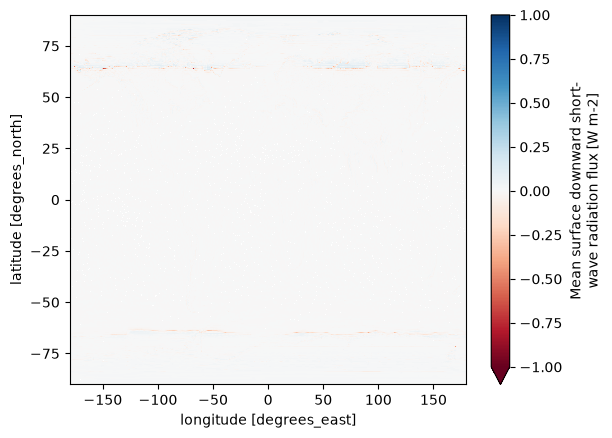

simple_rolling, ssp245


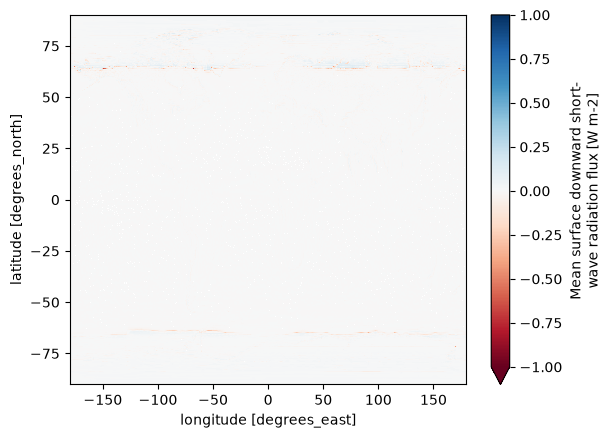

tiny_thresh, historical


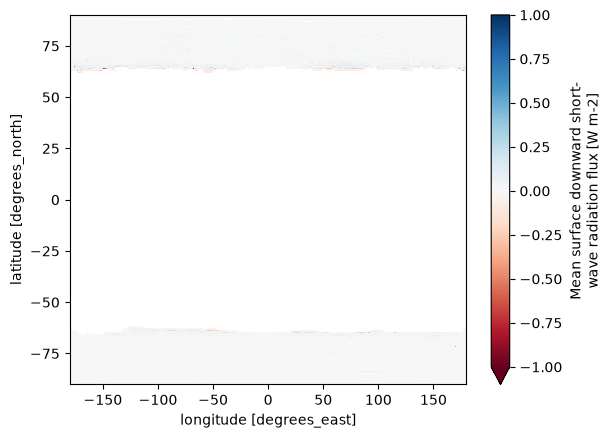

tiny_thresh, ssp245


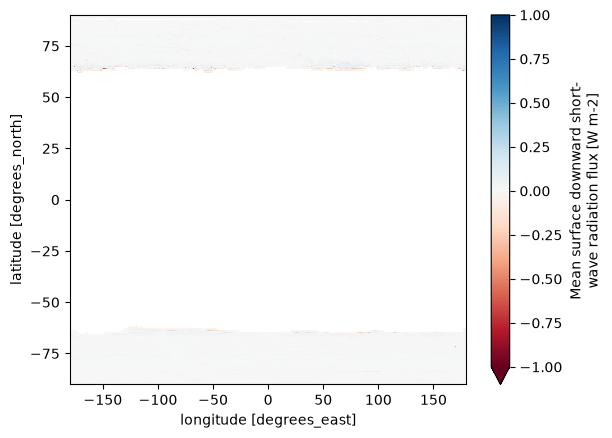

In [9]:
for (label, scenario), da in data.items():
    print(label + ", " + scenario)
    if label != "baseline":
        comp_mean = data[(label, scenario)].mean(dim="time")
        if scenario == "historical":
            delta = comp_mean - data_ref_hist
        elif scenario == "ssp245":
            delta = comp_mean - data_ref_ssp245
        delta.where(np.abs(delta) > 0).plot(vmax=1, vmin=-1, cmap=plt.cm.RdBu)
        plt.show()

## Sanity check: debiased_coarse should be identical across branches

PR #664's `simple_rolling`/`tiny_thresh` candidates only change the spatial-disaggregation step. `debiased_coarse` is written *before* disaggregation runs, so it should be bit-identical to `baseline`'s for the same scenario. This checks that directly rather than assuming it — a difference here would mean something upstream of disaggregation changed too, which would undermine treating the checks below as apples-to-apples disaggregation-only comparisons.

In [10]:
debiased_coarse_diffs = {}
for scenario in SCENARIOS:
    if ("baseline", scenario) not in data_coarse:
        print(f"skipping {scenario}: baseline debiased_coarse missing")
        continue
    baseline_da = data_coarse[("baseline", scenario)]
    for label in BRANCHES:
        if label == "baseline" or (label, scenario) not in data_coarse:
            continue
        diff = data_coarse[(label, scenario)] - baseline_da
        max_abs_diff = float(np.abs(diff).max().compute())
        debiased_coarse_diffs[(label, scenario)] = max_abs_diff
        identical = max_abs_diff == 0.0
        status = "identical" if identical else "DIFFERS -- investigate"
        print(f"{label} vs baseline / {scenario}: max abs diff = {max_abs_diff:.3e} ({status})")
        if not identical:
            diff.max(dim="time").plot()
            plt.title(f"{label} - baseline debiased_coarse, {scenario} (max over time)")
            plt.show()

simple_rolling vs baseline / historical: max abs diff = 0.000e+00 (identical)
tiny_thresh vs baseline / historical: max abs diff = 0.000e+00 (identical)
simple_rolling vs baseline / ssp245: max abs diff = 0.000e+00 (identical)
tiny_thresh vs baseline / ssp245: max abs diff = 0.000e+00 (identical)


In [11]:
debiased_coarse_summary = pd.DataFrame(
    {
        f"{label}/{scenario}": {"max_abs_diff": diff}
        for (label, scenario), diff in debiased_coarse_diffs.items()
    }
).T
debiased_coarse_summary

,max_abs_diff
simple_rolling/historical,0.0
tiny_thresh/historical,0.0
simple_rolling/ssp245,0.0
tiny_thresh/ssp245,0.0


## Shared helpers: area-weighted flag summaries

`trend_distortion`/`flipped_sign` (Evaluation 3) are time-invariant already (2D, no `time` dim) — `summarize_flag` handles those directly. Every other check here (`rsds_max_exceeded`, `annual_outlier_flag`, `outside_global_plausible_range`) is time-varying, but nothing downstream ever needs a single day's value: the plots are always a time-aggregate map and the summary stats are always totals/fractions over all time. So each of those is reduced over `time` **once** right after it's computed, and both the plot and `summarize_flag_count` reuse that one small 2D count — instead of the full per-day array getting re-read from S3 and re-reduced separately for the plot and again for each summary stat.

In [12]:
def summarize_flag(flag: xr.DataArray) -> dict:
    """For time-invariant (already 2D) flags -- trend_distortion/flipped_sign."""
    weights = area_weights(flag["lat"])
    flagged = int(flag.sum().compute())
    pct_flagged = 100 * flagged / flag.size
    area_weighted_pct = 100 * float(flag.astype("float64").weighted(weights).mean().compute())
    return {
        "flagged_cells": flagged,
        "pct_flagged": pct_flagged,
        "area_weighted_pct": area_weighted_pct,
    }


def summarize_flag_count(count: xr.DataArray, n_time: int) -> dict:
    """For time-varying flags, given a per-pixel day count (flag.sum(dim='time'), already
    computed once) and the number of days it was summed over -- avoids re-touching the full
    per-day array a second time just to get summary stats.
    """
    weights = area_weights(count["lat"])
    flagged = int(count.sum().compute())
    pct_flagged = 100 * flagged / (count.size * n_time)
    frac_flagged = count / n_time
    area_weighted_pct = 100 * float(frac_flagged.weighted(weights).mean().compute())
    return {
        "flagged_pixel_days": flagged,
        "pct_flagged": pct_flagged,
        "area_weighted_pct": area_weighted_pct,
    }

## Evaluation 1: unrealistic rsds values (zonal day-of-year max)

`flag_rsds_above_max` against the cached `zonal_doy_max_rsds` ceiling built in `flag_step1_produce-datasets-for-qa-flags.ipynb` (max downwelling solar radiation across all longitudes in a latitude band, unioned across ERA5 and three GCMs' historical/g6/ssp245 scenarios). This only checks the high side.

This ceiling is defined on ERA5's fine grid, so it only applies to `data` (the fine-resolution downscaled output), not `data_coarse` (native GCM grid) — see the plausible-range bonus check below for a grid-independent check that also covers `debiased_coarse`.

In [13]:
zonal_doy_max_rsds = xr.open_zarr(
    DIR_QA_FLAG_CONSTANT_INPUTS + "zonal_doy_max_rsds.zarr", group="zonal_doy_max_rsds"
)["data"].load()

(0.0, 30.0)

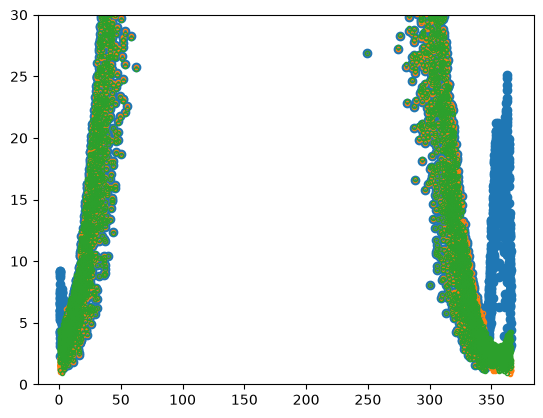

In [14]:
[pt_lat, pt_lon] = [64, -149]
plt.plot(
    data["baseline", "historical"]["time.dayofyear"],
    data["baseline", "historical"].sel(lat=pt_lat, lon=pt_lon, method="nearest"),
    "o",
)
plt.plot(
    data["tiny_thresh", "historical"]["time.dayofyear"],
    data["tiny_thresh", "historical"].sel(lat=pt_lat, lon=pt_lon, method="nearest"),
    ".",
    fillstyle="none",
    label="tiny thresh",
)
plt.plot(
    data["simple_rolling", "historical"]["time.dayofyear"],
    data["simple_rolling", "historical"].sel(lat=pt_lat, lon=pt_lon, method="nearest"),
    ".",
    fillstyle="none",
    label="tiny thresh",
)
plt.ylim([0, 30])

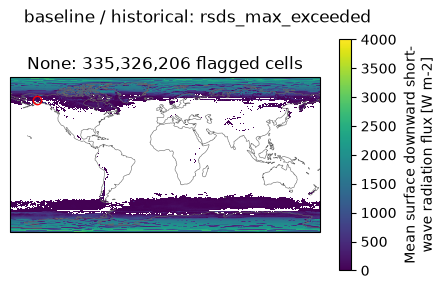

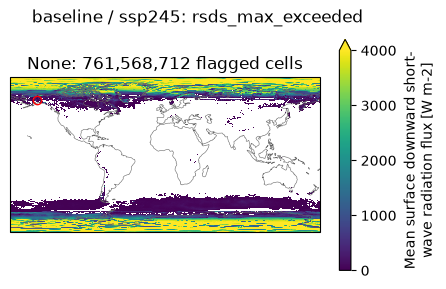

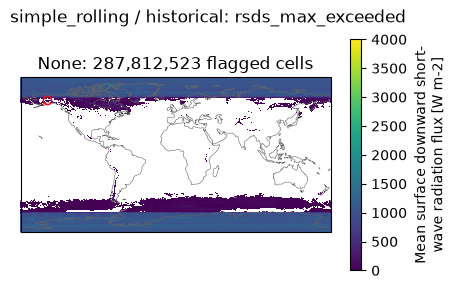

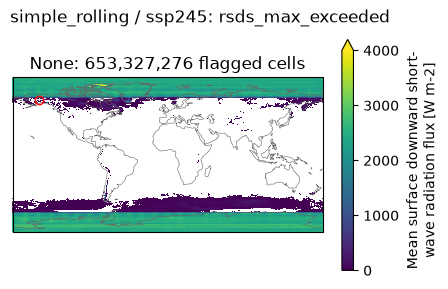

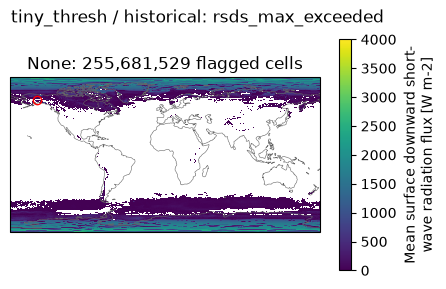

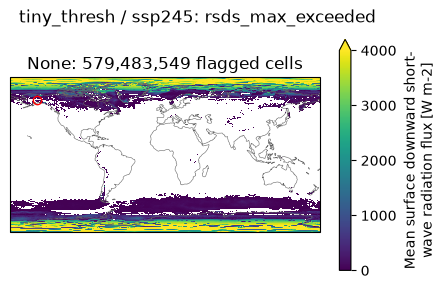

In [17]:
rsds_max_exceeded = {}
for (label, scenario), da in data.items():
    flag = flag_rsds_above_max(da, zonal_doy_max_rsds=zonal_doy_max_rsds)
    flag_count = flag.sum(dim="time").load()
    rsds_max_exceeded[(label, scenario)] = flag_count
    plot_flags(flags=flag_count, time_varying=False, separate_low_high=False, vlims=[0, 4000])
    plt.suptitle(f"{label} / {scenario}: rsds_max_exceeded")
    plt.plot([-149], [64], "or", fillstyle="none")
    plt.show()

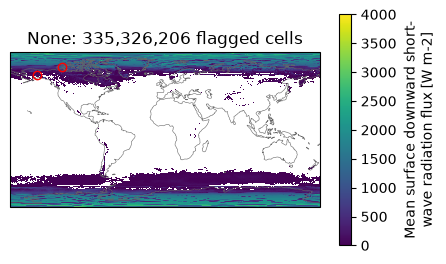

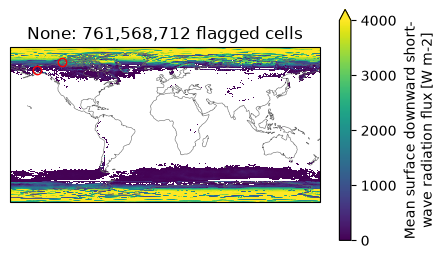

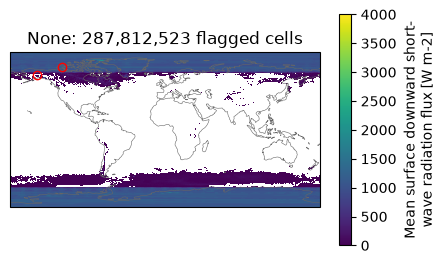

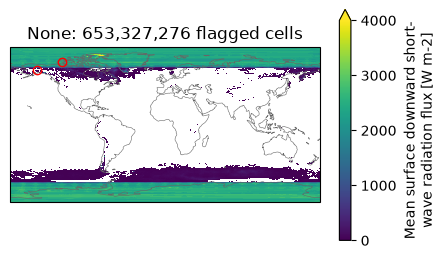

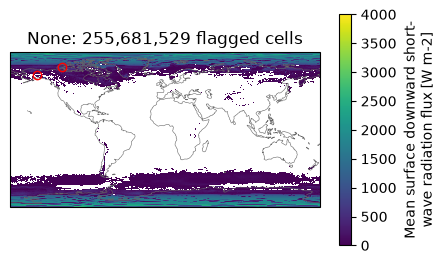

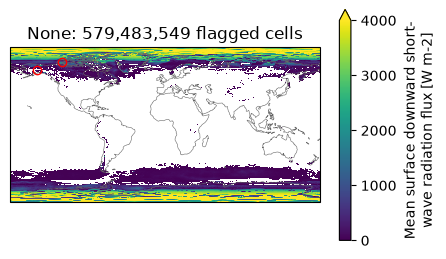

In [18]:
for (label, scenario), da in data.items():
    flag = rsds_max_exceeded[(label, scenario)]
    plot_flags(flags=flag, time_varying=False, separate_low_high=False, vlims=[0, 4000])
    plt.plot([-149], [64], "or", fillstyle="none")
    plt.plot([-120], [73], "or", fillstyle="none")
    plt.show()

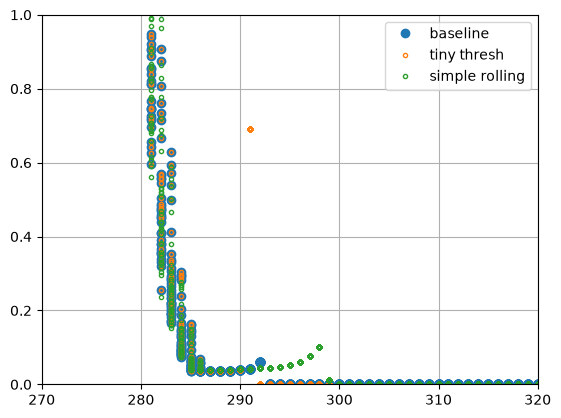

In [19]:
[pt_lat, pt_lon] = [83, -120]
plt.plot(
    data["baseline", "historical"]["time.dayofyear"],
    data["baseline", "historical"].sel(lat=pt_lat, lon=pt_lon, method="nearest"),
    "o",
    label="baseline",
)
plt.plot(
    data["tiny_thresh", "historical"]["time.dayofyear"],
    data["tiny_thresh", "historical"].sel(lat=pt_lat, lon=pt_lon, method="nearest"),
    ".",
    fillstyle="none",
    label="tiny thresh",
)
plt.plot(
    data["simple_rolling", "historical"]["time.dayofyear"],
    data["simple_rolling", "historical"].sel(lat=pt_lat, lon=pt_lon, method="nearest"),
    ".",
    fillstyle="none",
    label="simple rolling",
)
plt.ylim([0, 1])
plt.xlim([270, 320])
plt.grid()
plt.legend()

In [20]:
da = data_coarse[("baseline", "ssp245")]
flag_coarse = flag_rsds_above_max(da, zonal_doy_max_rsds=zonal_doy_max_rsds)

In [21]:
flag_coarse

<xarray.DataArray (time: 31046, lat: 2, lon: 288)> Size: 18MB
dask.array<gt, shape=(31046, 2, 288), dtype=bool, chunksize=(1095, 2, 180), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 248kB 2015-01-01 2015-01-02 ... 2099-12-31
    dayofyear  (time) int64 248kB 1 2 3 4 5 6 7 ... 359 360 361 362 363 364 365
  * lat        (lat) float64 16B -90.0 90.0
  * lon        (lon) float64 2kB -180.0 -178.8 -177.5 ... 176.2 177.5 178.8
    height     float64 8B 2.0
Attributes:
    long_name:   Mean surface downward short-wave radiation flux
    short_name:  msdwswrf
    units:       W m-2

In [22]:
rsds_max_summary = pd.DataFrame(
    {
        f"{label}/{scenario}": summarize_flag_count(
            count, n_time=data[(label, scenario)].sizes["time"]
        )
        for (label, scenario), count in rsds_max_exceeded.items()
    }
).T
rsds_max_summary

,flagged_pixel_days,pct_flagged,area_weighted_pct
baseline/historical,335326206.0,2.389934,0.586045
baseline/ssp245,761568712.0,2.362684,0.571569
simple_rolling/historical,287812523.0,2.051294,0.645873
simple_rolling/ssp245,653327276.0,2.026877,0.633344
tiny_thresh/historical,255681529.0,1.822291,0.382072
tiny_thresh/ssp245,579483549.0,1.797785,0.369269


## Evaluation 2: annual outliers vs the ERA5 observational record

`flag_outliers` against the cached day-of-year ERA5 thresholds, collapsed to a single annual bound the same way production's `annual_outlier_flag` does (`flag_step2_generate-intermediate-qa-flags.ipynb`, section 2).

Also ERA5-fine-grid-only, same reason as Evaluation 1 — `data` only, not `data_coarse`.

In [23]:
combined = xr.open_zarr(DIR_QA_FLAG_CONSTANT_INPUTS + "doy_obs_thresholds_global.zarr")


def _split(ds, suffix):
    names = [v for v in ds.data_vars if v.endswith(suffix)]
    return ds[names].rename({v: v[: -len(suffix)] for v in names})


obs_max = _split(combined, "_max")
obs_min = _split(combined, "_min")
obs_max_std = _split(combined, "_max_std")
obs_min_std = _split(combined, "_min_std")

outlier_thresh_low, outlier_thresh_high = calculate_thresholds(
    obs_max, obs_min, obs_max_std, obs_min_std
)
outlier_thresh_low_annual = outlier_thresh_low.min(dim="dayofyear")[VAR]
outlier_thresh_high_annual = outlier_thresh_high.max(dim="dayofyear")[VAR]

/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(


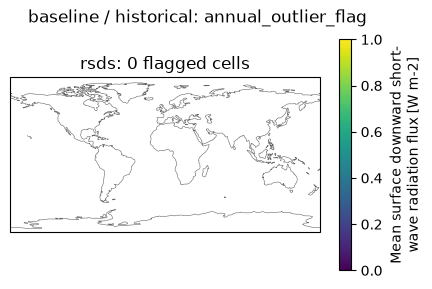

/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 29
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 29
  result = blockwise(


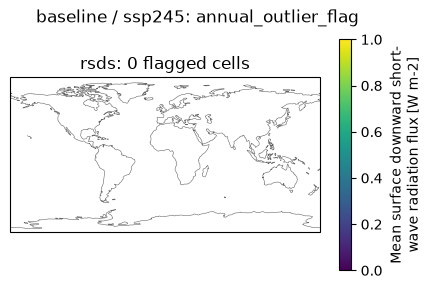

/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(


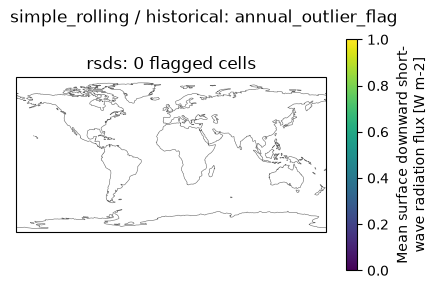

/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 29
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 29
  result = blockwise(


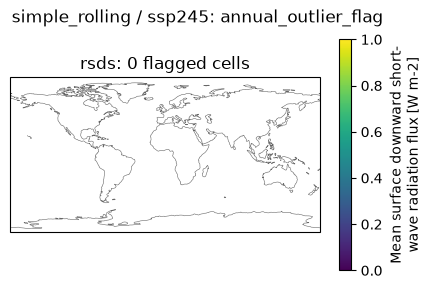

/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 18
  result = blockwise(


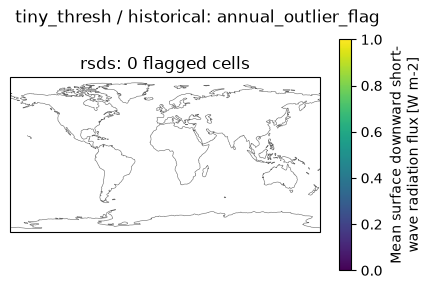

/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 29
  result = blockwise(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:5201: PerformanceWarning: Increasing number of chunks by factor of 29
  result = blockwise(


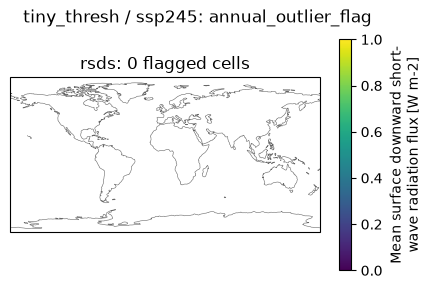

In [24]:
annual_outlier_flag = {}
for (label, scenario), da in data.items():
    flag = flag_outliers(
        da=da,
        outlier_thresh_low=outlier_thresh_low_annual,
        outlier_thresh_high=outlier_thresh_high_annual,
        timescale="annual",
    )
    flag_count = flag.sum(dim="time").load()
    annual_outlier_flag[(label, scenario)] = flag_count
    plot_flags(flags=flag_count, time_varying=False, separate_low_high=False)
    plt.suptitle(f"{label} / {scenario}: annual_outlier_flag")
    plt.show()

In [25]:
annual_outlier_summary = pd.DataFrame(
    {
        f"{label}/{scenario}": summarize_flag_count(
            count, n_time=data[(label, scenario)].sizes["time"]
        )
        for (label, scenario), count in annual_outlier_flag.items()
    }
).T
annual_outlier_summary

,flagged_pixel_days,pct_flagged,area_weighted_pct
baseline/historical,0.0,0.0,0.0
baseline/ssp245,0.0,0.0,0.0
simple_rolling/historical,0.0,0.0,0.0
simple_rolling/ssp245,0.0,0.0,0.0
tiny_thresh/historical,0.0,0.0,0.0
tiny_thresh/ssp245,0.0,0.0,0.0


## Bonus check: global plausible-range exceedances

`flag_rsds_above_max` above only bounds the *high* side, and only applies to the fine-grid downscaled output. `flag_global_exceedances` (against `VAR_SPATIAL_RANGES["rsds"]`, min 0–100 W/m2) checks a fixed numeric range rather than comparing against another grid, so it's the one check here that runs on **both** `data` (downscaled) and `data_coarse` (debiased_coarse) — relevant because the near-zero-climatology division that both PR #664 candidates are trying to fix is exactly the kind of bug that can also produce implausible or negative values, not just spikes, and could in principle show up at either stage.

In [26]:
var_range = VAR_SPATIAL_RANGES["rsds"]
var_min = var_range["min"][0]
var_max = var_range["max"][1]

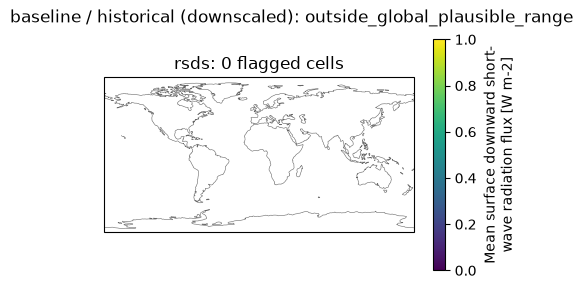

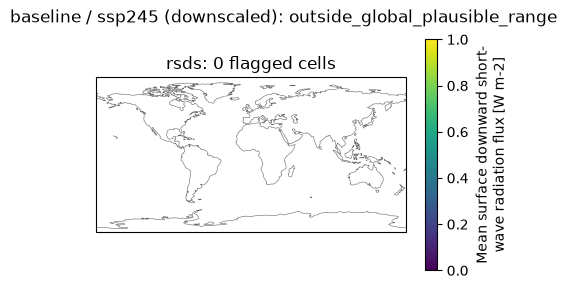

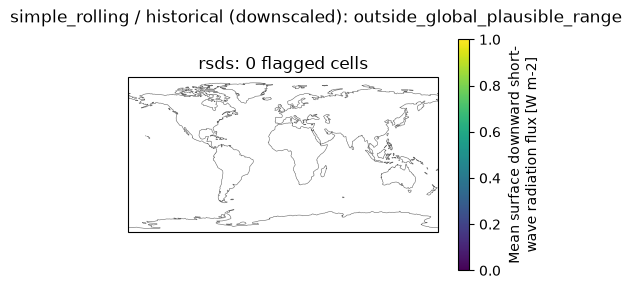

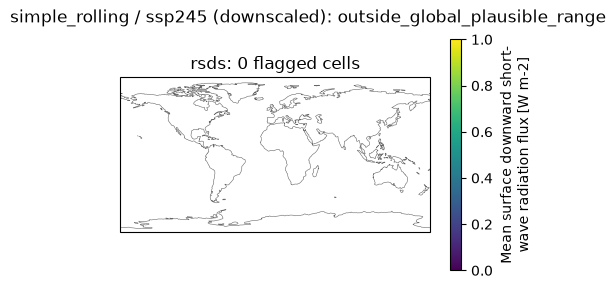

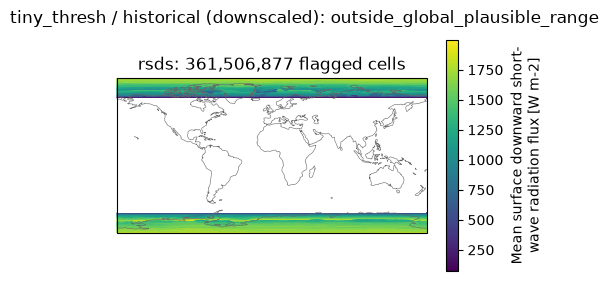

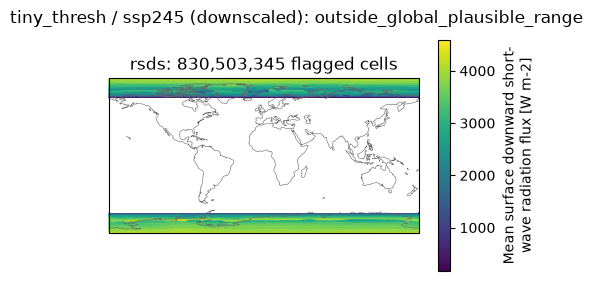

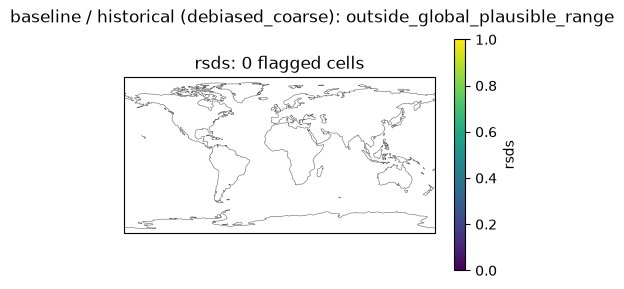

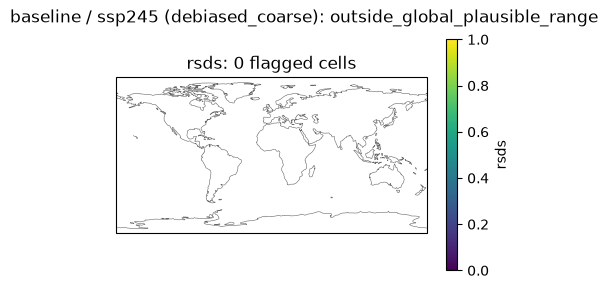

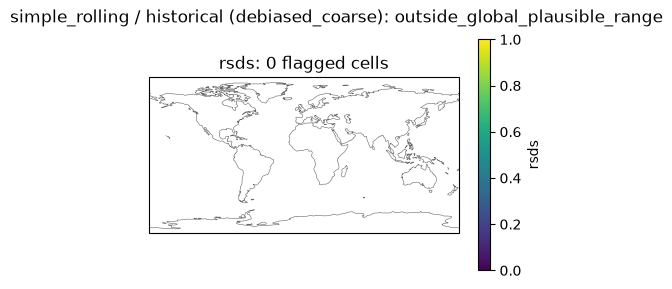

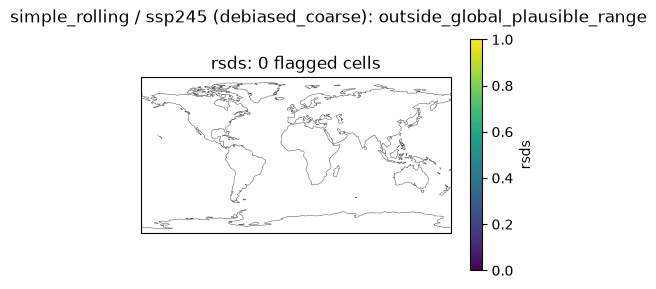

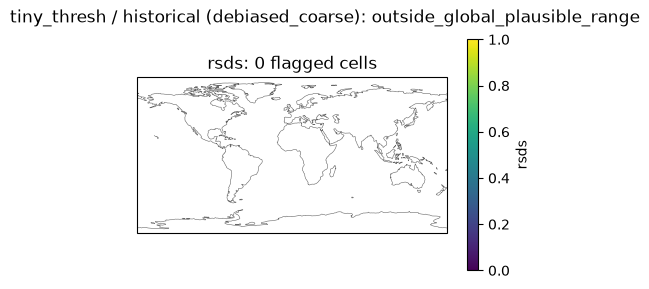

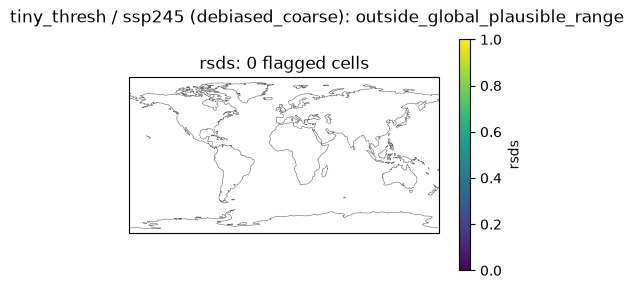

In [27]:
global_exceedance_flag = {}
for (label, scenario), da in data.items():
    flag = flag_global_exceedances(da=da, var=VAR)
    flag_count = flag.sum(dim="time").load()
    global_exceedance_flag[(label, scenario, "downscaled")] = flag_count
    plot_flags(flags=flag_count, time_varying=False, separate_low_high=False)
    plt.suptitle(f"{label} / {scenario} (downscaled): outside_global_plausible_range")
    plt.show()

for (label, scenario), da in data_coarse.items():
    flag = flag_global_exceedances(da=da, var=VAR)
    flag_count = flag.sum(dim="time").load()
    global_exceedance_flag[(label, scenario, "debiased_coarse")] = flag_count
    plot_flags(flags=flag_count, time_varying=False, separate_low_high=False)
    plt.suptitle(f"{label} / {scenario} (debiased_coarse): outside_global_plausible_range")
    plt.show()

In [28]:
def _n_time_for(label, scenario, source):
    return (data if source == "downscaled" else data_coarse)[(label, scenario)].sizes["time"]


global_exceedance_summary = pd.DataFrame(
    {
        f"{label}/{scenario}/{source}": summarize_flag_count(
            count, n_time=_n_time_for(label, scenario, source)
        )
        for (label, scenario, source), count in global_exceedance_flag.items()
    }
).T
global_exceedance_summary

,flagged_pixel_days,pct_flagged,area_weighted_pct
baseline/historical/downscaled,0.0,0.000000,0.000000
baseline/ssp245/downscaled,0.0,0.000000,0.000000
simple_rolling/historical/downscaled,0.0,0.000000,0.000000
simple_rolling/ssp245/downscaled,0.0,0.000000,0.000000
tiny_thresh/historical/downscaled,361506877.0,2.576528,0.702287
tiny_thresh/ssp245/downscaled,830503345.0,2.576546,0.702303
baseline/historical/debiased_coarse,0.0,0.000000,0.000000
baseline/ssp245/debiased_coarse,0.0,0.000000,0.000000
simple_rolling/historical/debiased_coarse,0.0,0.000000,0.000000
simple_rolling/ssp245/debiased_coarse,0.0,0.000000,0.000000


## Evaluation 3: trend distortion, historical → SSP245 (single ensemble member)

Reuses production's scenario-intercomparison distortion check: `calculate_ensemble_mean_deltas` (coarsens the downscaled output back to native GCM resolution and compares its historical→SSP245 delta against the same delta computed on the raw, undebiased GCM output) feeding `calculate_distortion_flags` (magnitude/percent distortion) and `sign_flip_mask` (does debiasing+downscaling flip the sign of the implied change). Uses `SCENARIO_COMPARISONS["ssp245_hist"]`'s time slices (historical 1978–2014 vs. SSP245 2065–2084) and `TREND_VARIABLE_SETTINGS["rsds"]`'s tolerances, both already tuned for this comparison in production.

Only run for branches where both `historical` and `ssp245` rsds leaves exist (see availability check above) — `simple_rolling` is skipped until its `ssp245/rsds` leaf lands.

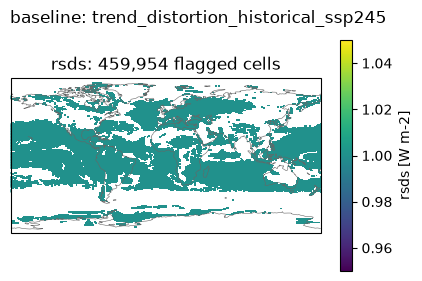

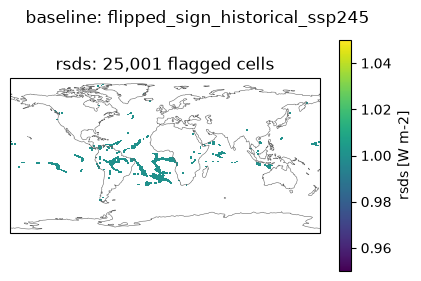

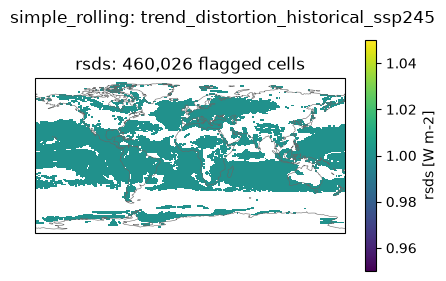

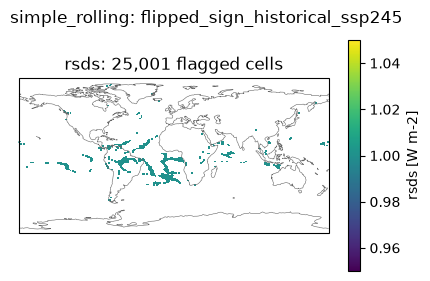

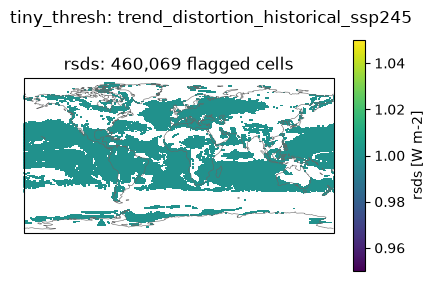

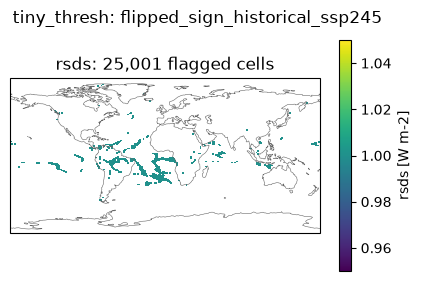

In [29]:
comparison = SCENARIO_COMPARISONS["ssp245_hist"]
settings = TREND_VARIABLE_SETTINGS[VAR]

trend_distortion_flag_fine = {}
flipped_sign_flag_fine = {}

for label in BRANCHES:
    if not (
        availability[label]["historical"]["downscaled"]
        and availability[label]["ssp245"]["downscaled"]
    ):
        print(f"skipping {label}: missing historical and/or ssp245 rsds output")
        continue

    tag_hist = f"{GCM}_{VAR}_historical_{ENSEMBLE_BY_SCENARIO['historical']}_{METHOD}"
    tag_ssp = f"{GCM}_{VAR}_ssp245_{ENSEMBLE_BY_SCENARIO['ssp245']}_{METHOD}"

    delta_raw, delta_raw_pct, delta_ds_coarse, delta_ds_coarse_pct, delta_ds = (
        calculate_ensemble_mean_deltas(
            variable=VAR,
            tags_scenario1=[tag_hist],
            tags_scenario2=[tag_ssp],
            gcm=GCM,
            scenario1=comparison["scenario1"],
            scenario2=comparison["scenario2"],
            scenario1_time_slice=comparison["scenario1_time_slice"],
            scenario2_time_slice=comparison["scenario2_time_slice"],
            trees={GCM: trees[label]},
        )
    )

    distortion_absolute = delta_ds_coarse - delta_raw
    distortion_pct = delta_ds_coarse_pct - delta_raw_pct

    trend_distortion_flag = calculate_distortion_flags(
        distortion_absolute=distortion_absolute * settings["scale"],
        distortion_pct=distortion_pct,
        tolerance_absolute=settings["abs_tol"],
        tolerance_pct=settings["pct_tol"],
    )
    flipped_sign_flag = sign_flip_mask(
        delta_ds_coarse * settings["scale"],
        delta_raw * settings["scale"],
        threshold=settings["sign_flip"],
    )

    trend_distortion_flag_fine[label] = (
        interpolate_coarse_to_fine_grid(
            da_coarse_to_regrid=trend_distortion_flag.astype("float32"), da_fine_grid=delta_ds
        )
        > 0
    )
    flipped_sign_flag_fine[label] = (
        interpolate_coarse_to_fine_grid(
            da_coarse_to_regrid=flipped_sign_flag.astype("float32"), da_fine_grid=delta_ds
        )
        > 0
    )

    plot_flags(flags=trend_distortion_flag_fine[label], time_varying=False, separate_low_high=False)
    plt.suptitle(f"{label}: trend_distortion_historical_ssp245")
    plt.show()
    plot_flags(flags=flipped_sign_flag_fine[label], time_varying=False, separate_low_high=False)
    plt.suptitle(f"{label}: flipped_sign_historical_ssp245")
    plt.show()

In [30]:
trend_summary = pd.DataFrame(
    {
        **{
            f"{label}/trend_distortion": summarize_flag(flag)
            for label, flag in trend_distortion_flag_fine.items()
        },
        **{
            f"{label}/flipped_sign": summarize_flag(flag)
            for label, flag in flipped_sign_flag_fine.items()
        },
    }
).T
trend_summary

,flagged_cells,pct_flagged,area_weighted_pct
baseline/trend_distortion,459954.0,44.301318,56.410238
simple_rolling/trend_distortion,460026.0,44.308252,56.409500
tiny_thresh/trend_distortion,460069.0,44.312394,56.416835
baseline/flipped_sign,25001.0,2.408017,3.567722
simple_rolling/flipped_sign,25001.0,2.408017,3.567722
tiny_thresh/flipped_sign,25001.0,2.408017,3.567722


## Evaluation 4: historical mean bias vs. ERA5 observations

Everything above either checks internal plausibility (value ranges, trend distortion) or diffs branches against each other -- none of it compares the downscaled output to observations directly. This adds that basic sanity check: for each branch's historical run, how far off is the time-mean `rsds` from ERA5's time-mean over the same period, on the shared fine grid (`downscaled - obs`, same units as `rsds`)?

Deliberately kept to raw bias rather than percent bias. Percent bias divides by the observed mean, which blows up at exactly the near-zero-climatology (polar-night) cells this whole PR #664 investigation is about -- it would just reproduce the bug being investigated rather than diagnose it. Grid match between the downscaled output and ERA5 is asserted rather than assumed (downscaling targets the ERA5 grid, so no regrid should be needed, but this checks that directly).

In [31]:
obs_fine = catalog.get("ERA5").to_xarray()[VAR]

historical_bias = {}
for label in BRANCHES:
    if not availability[label]["historical"]["downscaled"]:
        print(f"skipping {label}: no historical downscaled output")
        continue

    da_hist = data[(label, "historical")]
    common_time = da_hist.indexes["time"].intersection(obs_fine.indexes["time"])
    da_mean = da_hist.sel(time=common_time).mean(dim="time").compute()
    obs_mean = obs_fine.sel(time=common_time).mean(dim="time").compute()

    assert (
        da_mean.sizes["lat"] == obs_mean.sizes["lat"]
        and da_mean.sizes["lon"] == obs_mean.sizes["lon"]
    ), (
        f"{label}: grid mismatch between downscaled output ({da_mean.sizes}) and ERA5 obs "
        f"({obs_mean.sizes}) -- regrid needed, don't trust a silent coordinate-intersection result"
    )

    historical_bias[label] = da_mean - obs_mean
    print(f"{label}: {len(common_time)} overlapping historical days vs. ERA5")

baseline: 13514 overlapping historical days vs. ERA5
simple_rolling: 13514 overlapping historical days vs. ERA5
tiny_thresh: 13514 overlapping historical days vs. ERA5


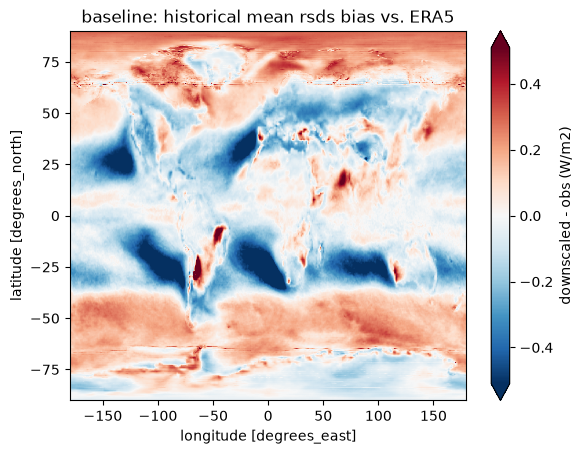

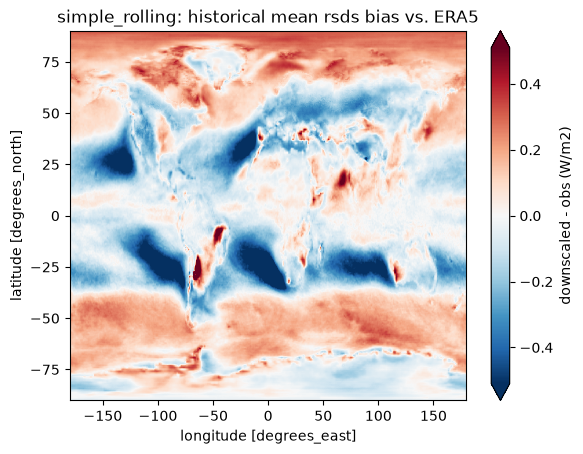

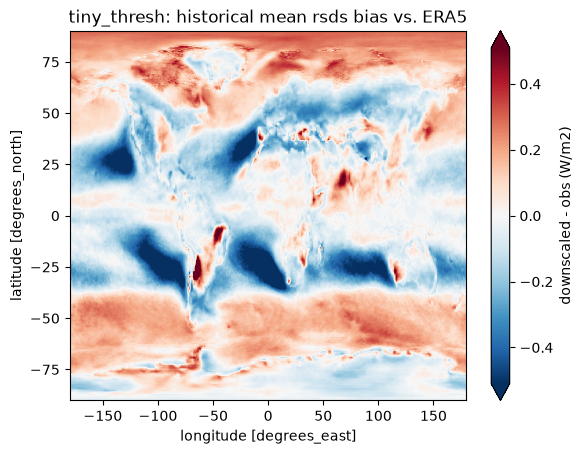

In [32]:
for label, bias in historical_bias.items():
    bias.plot(
        cmap=plt.cm.RdBu_r, center=0, robust=True, cbar_kwargs={"label": "downscaled - obs (W/m2)"}
    )
    plt.title(f"{label}: historical mean rsds bias vs. ERA5")
    plt.show()

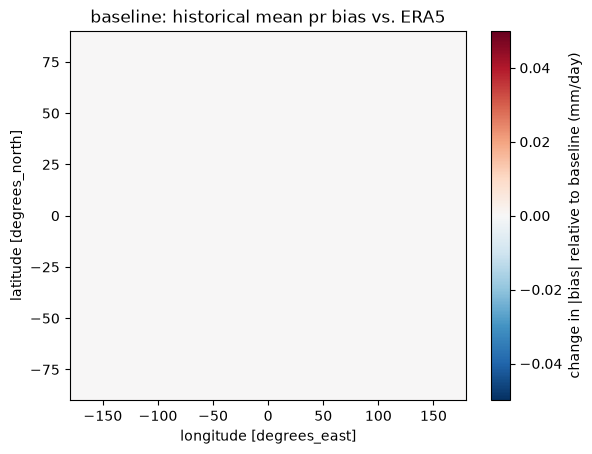

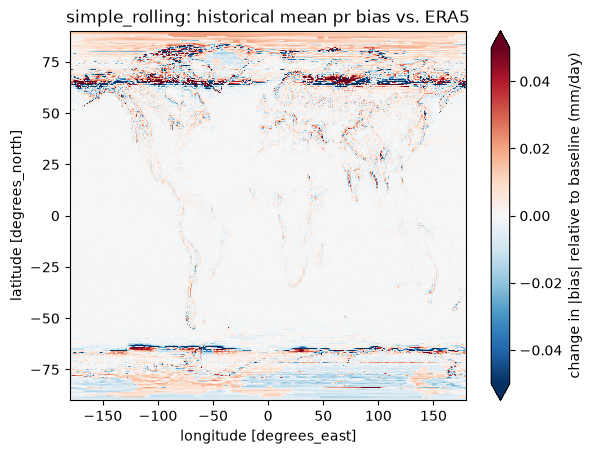

In [ ]:
ref_bias = historical_bias["baseline"]
for label, bias in historical_bias.items():
    (np.abs(bias) - np.abs(ref_bias)).plot(
        cmap=plt.cm.RdBu_r,
        center=0,
        vmin=-0.05,
        vmax=0.05,
        cbar_kwargs={"label": "change in |bias| relative to baseline (mm/day)"},
    )
    plt.title(f"{label}: historical mean pr bias vs. ERA5")
    plt.show()

In [33]:
def summarize_bias(bias: xr.DataArray) -> dict:
    weights = area_weights(bias["lat"])
    return {
        "mean_bias": float(bias.mean(skipna=True)),
        "mean_abs_bias": float(np.abs(bias).mean(skipna=True)),
        "area_weighted_mean_bias": float(bias.weighted(weights).mean(skipna=True)),
        "area_weighted_mean_abs_bias": float(np.abs(bias).weighted(weights).mean(skipna=True)),
    }


historical_bias_summary = pd.DataFrame(
    {label: summarize_bias(bias) for label, bias in historical_bias.items()}
).T
historical_bias_summary

,mean_bias,mean_abs_bias,area_weighted_mean_bias,area_weighted_mean_abs_bias
baseline,-0.003866,0.143241,-0.043320,0.142870
simple_rolling,-0.003002,0.143223,-0.043467,0.142673
tiny_thresh,-0.004044,0.142953,-0.043457,0.142648


## Side-by-side summary

All five checks, one table per branch/scenario/comparison. Lower is better everywhere except `historical_bias_vs_obs`, where the sign is informative (positive = branch too high vs. ERA5) and `mean_bias`/`area_weighted_mean_bias` can cancel across sign -- see `mean_abs_bias` for overall magnitude. `simple_rolling` rows will be incomplete until its `ssp245/rsds` leaf lands (see the gap noted at the top).

In [34]:
all_summary = pd.concat(
    {
        # "debiased_coarse_identity": debiased_coarse_summary,
        "rsds_max_exceeded": rsds_max_summary,
        "annual_outlier": annual_outlier_summary,
        "outside_global_plausible_range": global_exceedance_summary,
        "trend_distortion_or_sign_flip": trend_summary,
        "historical_bias_vs_obs": historical_bias_summary,
    },
    names=["check", "branch/scenario"],
)
all_summary

flagged_pixel_days  \
check                          branch/scenario                                                 
rsds_max_exceeded              baseline/historical                               335326206.0   
                               baseline/ssp245                                   761568712.0   
                               simple_rolling/historical                         287812523.0   
                               simple_rolling/ssp245                             653327276.0   
                               tiny_thresh/historical                            255681529.0   
                               tiny_thresh/ssp245                                579483549.0   
annual_outlier                 baseline/historical                                       0.0   
                               baseline/ssp245                                           0.0   
                               simple_rolling/historical                                 0.0   
                               simple_rolling/ssp245                                     0.0   
                               tiny_thresh/historical                                    0.0   
                               tiny_thresh/ssp245                                        0.0   
outside_global_plausible_range baseline/historical/downscaled                            0.0   
                               baseline/ssp245/downscaled                                0.0   
                               simple_rolling/historical/downscaled                      0.0   
                               simple_rolling/ssp245/downscaled                          0.0   
                               tiny_thresh/historical/downscaled                 361506877.0   
                               tiny_thresh/ssp245/downscaled                     830503345.0   
                               baseline/historical/debiased_coarse                       0.0   
                               baseline/ssp245/debiased_coarse                           0.0   
                               simple_rolling/historical/debiased_coarse                 0.0   
                               simple_rolling/ssp245/debiased_coarse                     0.0   
                               tiny_thresh/historical/debiased_coarse                    0.0   
                               tiny_thresh/ssp245/debiased_coarse                        0.0   
trend_distortion_or_sign_flip  baseline/trend_distortion                                 NaN   
                               simple_rolling/trend_distortion                           NaN   
                               tiny_thresh/trend_distortion                              NaN   
                               baseline/flipped_sign                                     NaN   
                               simple_rolling/flipped_sign                               NaN   
                               tiny_thresh/flipped_sign                                  NaN   
historical_bias_vs_obs         baseline                                                  NaN   
                               simple_rolling                                            NaN   
                               tiny_thresh                                               NaN   

                                                                          pct_flagged  \
check                          branch/scenario                                          
rsds_max_exceeded              baseline/historical                           2.389934   
                               baseline/ssp245                               2.362684   
                               simple_rolling/historical                     2.051294   
                               simple_rolling/ssp245                         2.026877   
                               tiny_thresh/historical                        1.822291   
                               tiny_thresh/ssp245                            1.797785   
a

## Other evaluations to consider

Not implemented here — worth adding if the four checks above come back clean or inconclusive for distinguishing `simple_rolling` from `tiny_thresh` (the earlier regional Alaska/rsds investigation found exactly this: `pct_implausible_days`-style checks were 0% for every method and weren't a useful discriminator, while more targeted diagnostics were):

- **Temporal-variance ratio vs. ERA5**, globally, especially at low-climatology (polar-night) cells: `simple_rolling` smooths the day-of-year climatology and could dampen real day-to-day variability there, while `tiny_thresh`'s override on specific days could introduce discontinuities. A std-ratio map (downscaled temporal std / ERA5 temporal std) surfaces this systematically instead of relying on one hand-picked point.
- **Zonal-mean seasonal-cycle drift**: disaggregation is supposed to redistribute the coarse-resolution signal spatially, not change the coarse-scale climatology itself. A zonal-mean seasonal cycle comparison across the three branches is a cheap sanity check that neither fix accidentally shifts the mean climatology.
- **Override/smoothing-magnitude diagnostic**: how often `tiny_thresh`'s override actually triggers vs. how much `simple_rolling`'s rolling mean actually changes the climatology, globally rather than at one edge-case point — explains *why* the two differ where they do, per the mechanism already documented for the regional comparison.